In [3]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

conn = sqlite3.connect('triage_results.db')
df = pd.read_sql('SELECT * FROM triage_results', conn)
conn.close()

print(f'Total rows: {len(df)}')
print(df['decision_source'].value_counts())
df.head(3)

Total rows: 92
decision_source
llm_judge       63
auto_discard    23
auto_keep        6
Name: count, dtype: int64


,id,run_id,article_id,source,title,body,published_at,retrieved_at,keep,final_score,lexical_score,semantic_score,freshness_score,predicted_category,rank_score,fused_score,decision_source,llm_reason,llm_relevance_score
0,1,dc58d294-bc7d-4bbe-a430-8fbe7c203610,t3_1s5ebri,reddit,Anyone else having cloudflare issues again?,It seems like I am not alone: https://downdete...,2026-03-27T19:38:36+00:00,2026-03-27T19:56:09.412749Z,1,0.780000,0.685447,0.681424,0.998258,service_outage,0.823652,0.745998,llm_judge,Reports of widespread Cloudflare-related 502 e...,78.0
1,2,dc58d294-bc7d-4bbe-a430-8fbe7c203610,t3_1s5eb11,reddit,Nutanix hit us with a 75% quote increase with ...,We were looking to get off VMware and refresh ...,2026-03-27T19:37:49+00:00,2026-03-27T19:56:09.412749Z,1,0.764714,0.762057,0.672923,0.998181,vendor_advisory,0.811408,0.764714,auto_keep,,0.0
2,3,dc58d294-bc7d-4bbe-a430-8fbe7c203610,t3_1s5eajh,reddit,How to view contents of SV2I and V2I files?,Trying to view the contents of 15 year old SV2...,2026-03-27T19:37:22+00:00,2026-03-27T19:56:09.412749Z,0,0.180000,0.000000,0.610346,0.998136,major_bug_patch,0.000000,0.504800,llm_judge,Troubleshooting request about viewing legacy b...,18.0


## 1. Fused score distribution — where do articles land?

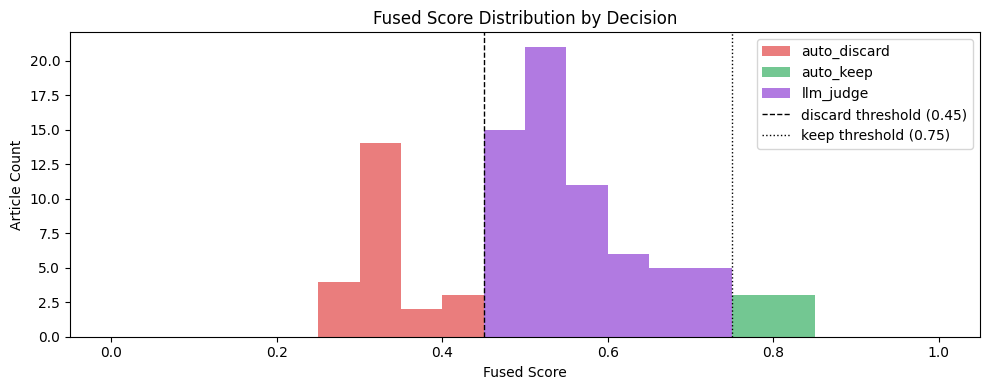

In [4]:
fig, ax = plt.subplots(figsize=(10, 4))

colors = {'auto_keep': '#16a34a', 'llm_judge': '#7e22ce', 'auto_discard': '#dc2626'}
for dec, grp in df.groupby('decision_source'):
    ax.hist(grp['fused_score'], bins=20, alpha=0.6, label=dec, color=colors.get(dec, 'gray'), range=(0, 1))

ax.axvline(0.45, color='black', linestyle='--', linewidth=1, label='discard threshold (0.45)')
ax.axvline(0.75, color='black', linestyle=':',  linewidth=1, label='keep threshold (0.75)')

ax.set_xlabel('Fused Score')
ax.set_ylabel('Article Count')
ax.set_title('Fused Score Distribution by Decision')
ax.legend()
plt.tight_layout()
plt.show()

## 2. LLM zone — what does the LLM actually do with articles in 0.45–0.75?

In [5]:
llm = df[df['decision_source'] == 'llm_judge'].copy()
llm['bucket'] = pd.cut(llm['fused_score'], bins=[0.45, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75])

summary = llm.groupby('bucket', observed=True).agg(
    count=('keep', 'count'),
    kept=('keep', 'sum'),
    keep_rate=('keep', 'mean'),
    avg_llm_score=('llm_relevance_score', 'mean'),
).reset_index()
summary['discard_rate'] = 1 - summary['keep_rate']
print(summary.to_string(index=False))

     bucket  count  kept  keep_rate  avg_llm_score  discard_rate
(0.45, 0.5]     15     7   0.466667      52.666667      0.533333
(0.5, 0.55]     21     6   0.285714      43.428571      0.714286
(0.55, 0.6]     11     1   0.090909      28.909091      0.909091
(0.6, 0.65]      6     4   0.666667      66.833333      0.333333
(0.65, 0.7]      5     4   0.800000      72.400000      0.200000
(0.7, 0.75]      5     1   0.200000      38.800000      0.800000


## 2b. LLM zone — keep/discard split by bucket AND source

outcome                   kept  discarded  total  keep_rate
bucket      source                                         
(0.45, 0.5] ars-technica     7          1      8       0.88
            reddit           0          7      7       0.00
(0.5, 0.55] ars-technica     5          2      7       0.71
            reddit           1         13     14       0.07
(0.55, 0.6] ars-technica     1          0      1       1.00
            reddit           0         10     10       0.00
(0.6, 0.65] ars-technica     3          0      3       1.00
            reddit           1          2      3       0.33
(0.65, 0.7] ars-technica     3          0      3       1.00
            reddit           1          1      2       0.50
(0.7, 0.75] reddit           1          4      5       0.20


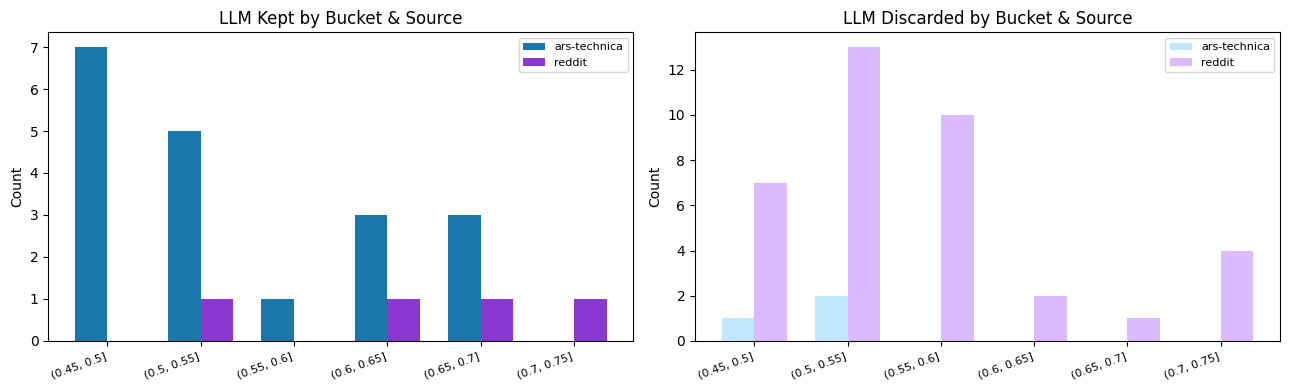

In [12]:
# Cross-tab: bucket × source — counts + keep rate
llm['outcome'] = llm['keep'].map({1: 'kept', 0: 'discarded'})

cross = llm.groupby(['bucket', 'source', 'outcome'], observed=True).size().unstack(fill_value=0)
if 'kept'      not in cross.columns: cross['kept']      = 0
if 'discarded' not in cross.columns: cross['discarded'] = 0
cross['total']     = cross['kept'] + cross['discarded']
cross['keep_rate'] = (cross['kept'] / cross['total']).round(2)
print(cross[['kept', 'discarded', 'total', 'keep_rate']].to_string())

# Bar chart: per bucket, grouped by source, kept vs discarded side by side
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=False)
sources       = sorted(llm['source'].unique())
bucket_labels = summary['bucket'].astype(str).tolist()
x             = list(range(len(bucket_labels)))
width         = 0.35
src_colors    = {
    'reddit':       {'kept': '#7e22ce', 'discarded': '#d8b4fe'},
    'ars-technica': {'kept': '#0369a1', 'discarded': '#bae6fd'},
}
offsets = [-width / 2, width / 2]

for ax_i, outcome in enumerate(['kept', 'discarded']):
    ax = axes[ax_i]
    for i, src in enumerate(sources):
        counts = []
        for bucket in summary['bucket']:
            mask = (llm['bucket'] == bucket) & (llm['source'] == src) & (llm['outcome'] == outcome)
            counts.append(int(mask.sum()))
        color = src_colors.get(src, {}).get(outcome, 'gray')
        ax.bar([xi + offsets[i] for xi in x], counts, width=width, label=src, color=color, alpha=0.9)
    ax.set_title(f'LLM {outcome.capitalize()} by Bucket & Source')
    ax.set_xticks(x)
    ax.set_xticklabels(bucket_labels, rotation=20, ha='right', fontsize=8)
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

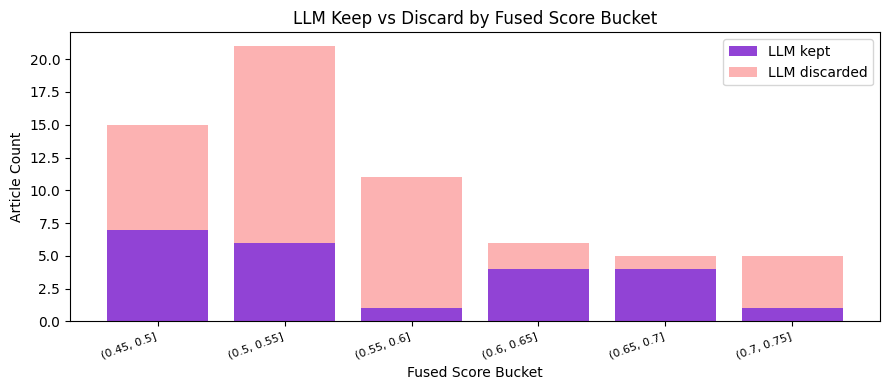

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))

buckets = summary['bucket'].astype(str)
x = range(len(buckets))
ax.bar(x, summary['kept'],                          label='LLM kept',     color='#7e22ce', alpha=0.85)
ax.bar(x, summary['count'] - summary['kept'],
       bottom=summary['kept'],                       label='LLM discarded',color='#fca5a5', alpha=0.85)

ax.set_xticks(list(x))
ax.set_xticklabels(buckets, rotation=20, ha='right', fontsize=8)
ax.set_xlabel('Fused Score Bucket')
ax.set_ylabel('Article Count')
ax.set_title('LLM Keep vs Discard by Fused Score Bucket')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Source breakdown — which source drives discards?

decision_source  auto_discard  auto_keep  llm_judge
source                                             
ars-technica               23          0         22
reddit                      0          6         41


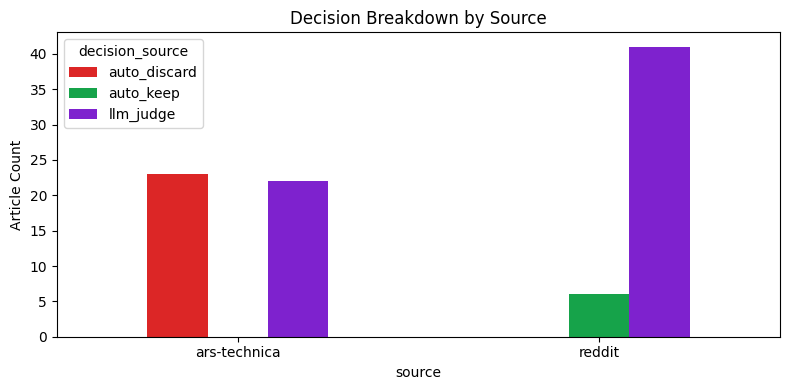

In [7]:
source_summary = df.groupby(['source', 'decision_source']).size().unstack(fill_value=0)
print(source_summary)

source_summary.plot(kind='bar', figsize=(8, 4), color=['#dc2626', '#16a34a', '#7e22ce'],
                    title='Decision Breakdown by Source')
plt.ylabel('Article Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 4. Score component breakdown — what's driving fused score for each decision?

In [8]:
cols = ['lexical_score', 'semantic_score', 'freshness_score', 'fused_score']
print(df.groupby('decision_source')[cols].mean().round(3).to_string())

                 lexical_score  semantic_score  freshness_score  fused_score
decision_source                                                             
auto_discard             0.030           0.642            0.019        0.334
auto_keep                0.837           0.662            0.952        0.798
llm_judge                0.314           0.658            0.657        0.559


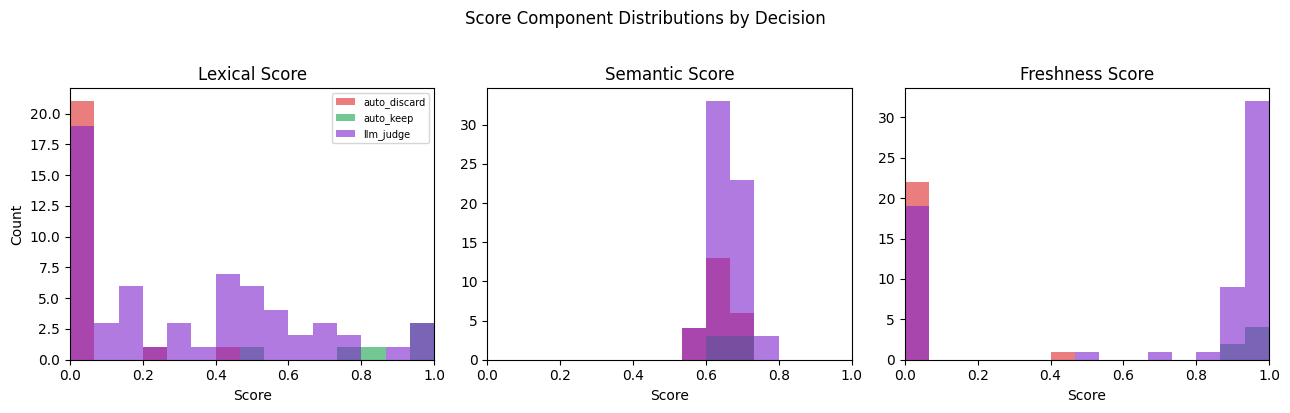

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=False)

score_cols = ['lexical_score', 'semantic_score', 'freshness_score']
titles     = ['Lexical Score', 'Semantic Score', 'Freshness Score']
palette    = {'auto_keep': '#16a34a', 'llm_judge': '#7e22ce', 'auto_discard': '#dc2626'}

for ax, col, title in zip(axes, score_cols, titles):
    for dec, grp in df.groupby('decision_source'):
        ax.hist(grp[col], bins=15, alpha=0.6, label=dec, color=palette.get(dec, 'gray'), range=(0, 1))
    ax.set_title(title)
    ax.set_xlabel('Score')
    ax.set_xlim(0, 1)

axes[0].set_ylabel('Count')
axes[0].legend(fontsize=7)
plt.suptitle('Score Component Distributions by Decision', y=1.02)
plt.tight_layout()
plt.show()

## 5. LLM relevance score vs fused score — are they correlated?

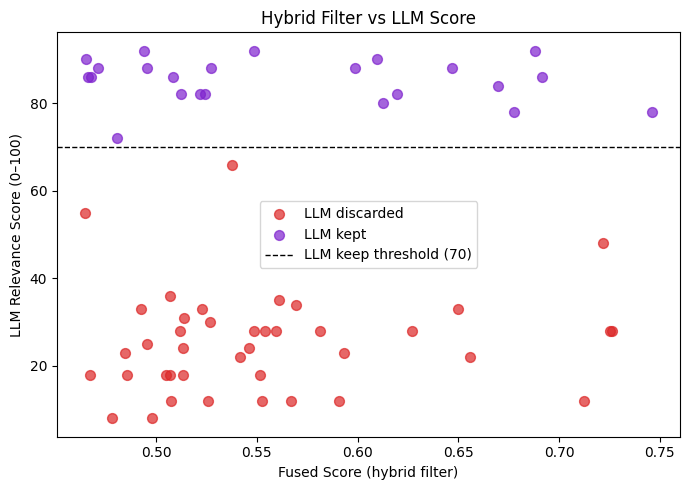

Pearson correlation (fused vs LLM score): 0.087


In [10]:
fig, ax = plt.subplots(figsize=(7, 5))

kept_llm     = llm[llm['keep'] == 1]
discarded_llm = llm[llm['keep'] == 0]

ax.scatter(discarded_llm['fused_score'], discarded_llm['llm_relevance_score'],
           color='#dc2626', alpha=0.7, label='LLM discarded', s=50)
ax.scatter(kept_llm['fused_score'],     kept_llm['llm_relevance_score'],
           color='#7e22ce', alpha=0.7, label='LLM kept',      s=50)

ax.axhline(70, color='black', linestyle='--', linewidth=1, label='LLM keep threshold (70)')
ax.set_xlabel('Fused Score (hybrid filter)')
ax.set_ylabel('LLM Relevance Score (0–100)')
ax.set_title('Hybrid Filter vs LLM Score')
ax.legend()
plt.tight_layout()
plt.show()

corr = llm[['fused_score', 'llm_relevance_score']].corr().iloc[0, 1]
print(f'Pearson correlation (fused vs LLM score): {corr:.3f}')

## 6. Full article list — sorted by fused score, all decisions visible

In [11]:
pd.set_option('display.max_colwidth', 80)
pd.set_option('display.max_rows', 100)

df.sort_values('fused_score', ascending=False)[[
    'source', 'decision_source', 'keep',
    'fused_score', 'lexical_score', 'semantic_score', 'freshness_score',
    'llm_relevance_score', 'title'
]].round(3)

,source,decision_source,keep,fused_score,lexical_score,semantic_score,freshness_score,llm_relevance_score,title
47,reddit,auto_keep,1,0.815,0.471,0.683,0.912,0.0,Exchange Online EWS outage?
37,reddit,auto_keep,1,0.814,1.000,0.649,0.948,0.0,"Intermittent ""Incorrect Password"" on SQL Nodes after DC Migration - dcdiag s..."
3,reddit,auto_keep,1,0.812,0.972,0.642,0.998,0.0,Troubleshooting Cisco SIG blocking VS code extensions
45,reddit,auto_keep,1,0.792,1.000,0.616,0.919,0.0,SMB Authentication After NTLM Is Disabled by Microsoft
42,reddit,auto_keep,1,0.787,0.816,0.709,0.939,0.0,"Windows secure boot certificate, how is this even possible?"
1,reddit,auto_keep,1,0.765,0.762,0.673,0.998,0.0,Nutanix hit us with a 75% quote increase with a one day notice before expira...
0,reddit,llm_judge,1,0.746,0.685,0.681,0.998,78.0,Anyone else having cloudflare issues again?
43,reddit,llm_judge,0,0.726,0.781,0.610,0.936,28.0,"OneDrive on Windows Server 2025 disappeared, cannot uninstall, and reinstall..."
48,reddit,llm_judge,0,0.725,0.783,0.618,0.906,28.0,PKI - Intermediate CA - certificate show old chain
52,reddit,llm_judge,0,0.722,0.679,0.681,0.888,48.0,Anybody dump their VMWare subscription and Roll back to Perpetual Licenses w...
